In [1]:
!pip install -q -U accelerate bitsandbytes qwen-vl-utils

User is already logged in. Use `hf auth login --force` to force re-login.


In [3]:
!hf auth login

import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


from huggingface_hub import hf_hub_download
os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"

path = hf_hub_download(
    repo_id="Mockini/fakeddit-images",
    filename="images.parquet",
    repo_type="dataset",
    local_dir="/content/fakeddit-images",
)

In [4]:
!ls -la /content

total 783964
drwxr-xr-x 1 root root      4096 Jun  4 18:12 .
drwxr-xr-x 1 root root      4096 Jun  4 18:08 ..
drwxr-xr-x 4 root root      4096 May 26 13:31 .config
-rw-r--r-- 1 root root 802750546 Jun  4 18:49 embeddings.parquet
drwxr-xr-x 3 root root      4096 Jun  4 18:10 fakeddit-images
drwxr-xr-x 1 root root      4096 May 26 13:31 sample_data


In [5]:
from io import BytesIO
from pathlib import Path

import numpy as np
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import torch
from PIL import Image
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

MODEL_ID = "Qwen/Qwen3-VL-Embedding-2B"

IMAGES_PARQUET_PATH     = Path("/content/fakeddit-images/images.parquet")
EMBEDDINGS_PARQUET_PATH = Path("/content/embeddings.parquet")

READ_BATCH_SIZE  = 32    # rows fetched from parquet per loop iteration
WRITE_BATCH_SIZE = 512   # flush to output parquet every N embeddings

In [6]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

model = SentenceTransformer(
    MODEL_ID,
    model_kwargs={"quantization_config": bnb_config},
)
model.eval()

print(f"Loaded {MODEL_ID}  |  embedding dim={model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded Qwen/Qwen3-VL-Embedding-2B  |  embedding dim=2048


/tmp/ipykernel_11721/4257558077.py:16: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Loaded {MODEL_ID}  |  embedding dim={model.get_sentence_embedding_dimension()}")


In [7]:
def embed_batch(clean_titles, image_bytes_list) -> np.ndarray:
    """Returns float32 array of shape [batch_size, 2048]."""
    inputs = [
        {"text": title or "", "image": Image.open(BytesIO(img)).convert("RGB")}
        for title, img in zip(clean_titles, image_bytes_list)
    ]
    return model.encode(inputs, convert_to_numpy=True, batch_size=len(inputs))

In [8]:
import gc
def cuda_cleanup():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

In [9]:
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm
import torch

EMBED_BATCH_SIZE = 512
READ_BATCH_SIZE = EMBED_BATCH_SIZE * 2
WRITE_BATCH_SIZE = EMBED_BATCH_SIZE * 4
CLEAN_AFTER_N_BATCHES = 100


pf = pq.ParquetFile(IMAGES_PARQUET_PATH)
total_rows = pf.metadata.num_rows

writer = None
rows_written = 0

ids_buf = []
labels_buf = []
splits_buf = []
embs_buf = []


def make_embedding_array(embs: np.ndarray) -> pa.FixedSizeListArray:
    """
    embs shape: [n, dim], dtype float32
    """
    embs = np.asarray(embs, dtype=np.float32)
    n, dim = embs.shape

    flat = pa.array(embs.reshape(-1), type=pa.float32())
    return pa.FixedSizeListArray.from_arrays(flat, list_size=dim)


def flush_buffer():
    global rows_written, writer

    if not ids_buf:
        return

    embs = np.concatenate(embs_buf, axis=0).astype(np.float32, copy=False)
    embedding_dim = embs.shape[1]

    schema = pa.schema([
        ("id", pa.string()),
        ("6_way_label", pa.int64()),
        ("split", pa.string()),
        ("embedding", pa.list_(pa.float32(), embedding_dim)),
    ])

    table = pa.Table.from_arrays(
        [
            pa.array(ids_buf, type=pa.string()),
            pa.array(labels_buf, type=pa.int64()),
            pa.array(splits_buf, type=pa.string()),
            make_embedding_array(embs),
        ],
        schema=schema,
    )

    if writer is None:
        writer = pq.ParquetWriter(
            str(EMBEDDINGS_PARQUET_PATH),
            schema,
            compression="zstd",
            use_dictionary=["split"],
        )

    writer.write_table(table)
    rows_written += len(ids_buf)

    ids_buf.clear()
    labels_buf.clear()
    splits_buf.clear()
    embs_buf.clear()



def chunks(xs, size):
    for start in range(0, len(xs), size):
        yield start, min(start + size, len(xs))

batch_idx = 0
try:
    with tqdm(total=total_rows, unit="img", desc="embedding") as pbar:
        for arrow_batch in pf.iter_batches(
            batch_size=READ_BATCH_SIZE,
            columns=["id", "6_way_label", "split", "clean_title", "image"],
        ):
            ids = arrow_batch.column("id").to_pylist()
            labels = arrow_batch.column("6_way_label").to_pylist()
            splits = arrow_batch.column("split").to_pylist()
            titles = arrow_batch.column("clean_title").to_pylist()
            images = arrow_batch.column("image").to_pylist()

            n = len(ids)

            for start, end in chunks(ids, EMBED_BATCH_SIZE):
                batch_titles = titles[start:end]
                batch_images = images[start:end]

                batch_embs = embed_batch(batch_titles, batch_images)
                batch_idx += 1

                ids_buf.extend(ids[start:end])
                labels_buf.extend(labels[start:end])
                splits_buf.extend(splits[start:end])
                embs_buf.append(batch_embs.astype(np.float32, copy=False))

                if len(ids_buf) >= WRITE_BATCH_SIZE:
                    flush_buffer()
                if batch_idx % CLEAN_AFTER_N_BATCHES == 0:
                    cuda_cleanup()


                pbar.update(end - start)

        flush_buffer()

finally:
    if writer is not None:
        writer.close()

print(f"Done: {rows_written:,} embeddings saved into {EMBEDDINGS_PARQUET_PATH}")

embedding:   0%|          | 0/261781 [00:00<?, ?img/s]

Done: 261,781 embeddings saved into /content/embeddings.parquet


In [ ]:
def preview_embeddings(path, n_rows=5):
    path = Path(path)
    lf = pl.scan_parquet(path)
    schema = lf.collect_schema()
    n_total = lf.select(pl.len()).collect().item()
    head = lf.head(n_rows).collect()

    print(f"{path.name}: {n_total:,} rows × {len(schema)} cols")

    for name, dtype in schema.items():
        # Use .size instead of .width to avoid DeprecationWarning in newer Polars
        if isinstance(dtype, pl.Array):
            suffix = f"  [dim={dtype.size}]"
        elif isinstance(dtype, pl.List):
            suffix = f"  [dim={len(head.get_column(name)[0])}]"
        else:
            suffix = ""
        print(f"  {name}: {dtype}{suffix}")

    # Drop the high-dimensional embedding column for a cleaner preview
    display_df = head.drop("embedding")
    display(display_df)

preview_embeddings(EMBEDDINGS_PARQUET_PATH)

train=(157410, 2048)  eval (val+test)=(104371, 2048)
Training until validation scores don't improve for 25 rounds
[25]	train's multi_logloss: 0.63445	eval's multi_logloss: 0.729999
[50]	train's multi_logloss: 0.473886	eval's multi_logloss: 0.614513
[75]	train's multi_logloss: 0.38306	eval's multi_logloss: 0.560898
[100]	train's multi_logloss: 0.319382	eval's multi_logloss: 0.529416
[125]	train's multi_logloss: 0.270772	eval's multi_logloss: 0.508493
[150]	train's multi_logloss: 0.231777	eval's multi_logloss: 0.494033
[175]	train's multi_logloss: 0.199633	eval's multi_logloss: 0.483834
[200]	train's multi_logloss: 0.172832	eval's multi_logloss: 0.476697
[225]	train's multi_logloss: 0.150136	eval's multi_logloss: 0.471451
[250]	train's multi_logloss: 0.130784	eval's multi_logloss: 0.467968
[275]	train's multi_logloss: 0.114214	eval's multi_logloss: 0.465925
[300]	train's multi_logloss: 0.0999792	eval's multi_logloss: 0.465017
[325]	train's multi_logloss: 0.0876891	eval's multi_logloss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Eval accuracy : 0.8483
Eval macro-F1 : 0.6978
              precision    recall  f1-score   support

           0       0.79      0.82      0.81     26037
           1       0.91      0.72      0.80      4656
           2       0.80      0.61      0.69     17383
           3       0.79      0.04      0.08       767
           4       0.88      0.96      0.92     53754
           5       0.96      0.82      0.88      1774

    accuracy                           0.85    104371
   macro avg       0.86      0.66      0.70    104371
weighted avg       0.85      0.85      0.84    104371



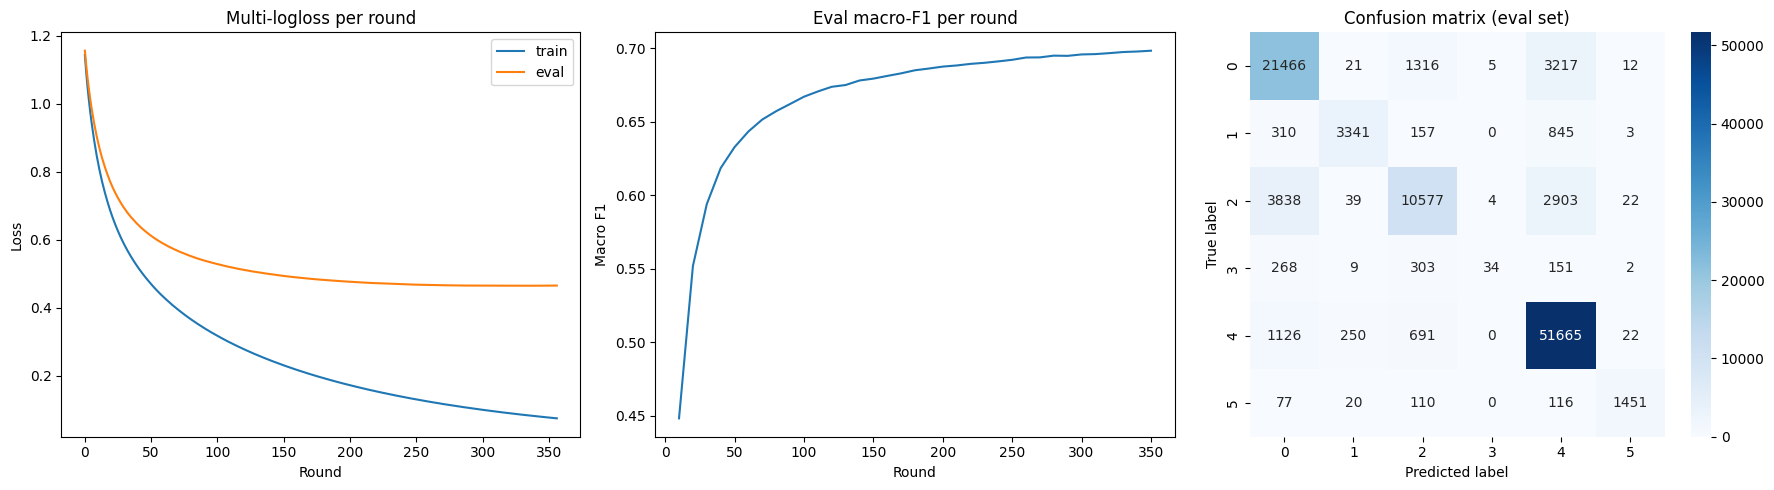

In [16]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
)

emb_df = pl.read_parquet(EMBEDDINGS_PARQUET_PATH)

def get_split(df, split_names):
    if isinstance(split_names, str):
        split_names = [split_names]
    s = df.filter(pl.col("split").is_in(split_names))
    X = np.stack(s.get_column("embedding").to_list()).astype(np.float32)
    y = s.get_column("6_way_label").to_numpy()
    return X, y

X_train, y_train = get_split(emb_df, "train")
X_eval, y_eval = get_split(emb_df, ["val", "test"])

print(f"train={X_train.shape}  eval (val+test)={X_eval.shape}")

class EvalF1Callback:
    def __init__(self, X_eval, y_eval, period=10):
        self.X_eval, self.y_eval = X_eval, y_eval
        self.period = period
        self.rounds, self.scores = [], []

    def __call__(self, env):
        if (env.iteration + 1) % self.period != 0:
            return
        preds = env.model.predict(self.X_eval).argmax(axis=1)
        self.scores.append(f1_score(self.y_eval, preds, average="macro"))
        self.rounds.append(env.iteration + 1)

eval_f1_cb = EvalF1Callback(X_eval, y_eval, period=10)
evals_result = {}

clf = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=6,
    n_estimators=1000,
    num_leaves=127,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    verbose=-1,
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_eval, y_eval)],
    eval_names=["train", "eval"],
    callbacks=[
        lgb.early_stopping(25, verbose=True),
        lgb.log_evaluation(25),
        lgb.record_evaluation(evals_result),
        eval_f1_cb,
    ],
)

y_pred = clf.predict(X_eval)
acc = accuracy_score(y_eval, y_pred)
macro_f1 = f1_score(y_eval, y_pred, average="macro")
print(f"\nEval accuracy : {acc:.4f}")
print(f"Eval macro-F1 : {macro_f1:.4f}")
print(classification_report(y_eval, y_pred))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(evals_result["train"]["multi_logloss"], label="train")
axes[0].plot(evals_result["eval"]["multi_logloss"],   label="eval")
axes[0].set_title("Multi-logloss per round")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(eval_f1_cb.rounds, eval_f1_cb.scores)
axes[1].set_title("Eval macro-F1 per round")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Macro F1")

cm = confusion_matrix(y_eval, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Confusion matrix (eval set)")
axes[2].set_xlabel("Predicted label")
axes[2].set_ylabel("True label")

plt.tight_layout()
plt.show()